<a href="https://colab.research.google.com/github/nikhilobulreddy2007-ship-it/AI-TRAVEL-PLANNER-python-project/blob/main/AI%20TRAVEL%20PLANNER_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_travel_data (project) (1).csv to final_travel_data (project) (1).csv


In [2]:
import os
print(os.listdir())

['.config', 'final_travel_data (project) (1).csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("final_travel_data (project) (1).csv")

print(df.head())

   UserID  DestinationID  Type  Rating  ExperienceRating  Popularity  Budget
0       1            941     3     NaN              1.00    0.571614    8575
1       1            467     1     NaN              0.50    0.261105    8055
2       2            385     0     NaN              1.00    0.273994   49165
3       2            437     1     NaN              0.25    0.241870   39462
4       3            904     4     NaN              0.75    0.536195   35628


In [4]:
df = df.drop(columns=['Rating'])
df = df.dropna()

print(df.head())

   UserID  DestinationID  Type  ExperienceRating  Popularity  Budget
0       1            941     3              1.00    0.571614    8575
1       1            467     1              0.50    0.261105    8055
2       2            385     0              1.00    0.273994   49165
3       2            437     1              0.25    0.241870   39462
4       3            904     4              0.75    0.536195   35628


In [5]:
features = df[['ExperienceRating', 'Popularity', 'Budget']]

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(features)

print(df.head())

   UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  Cluster
0       1            941     3              1.00    0.571614    8575        1
1       1            467     1              0.50    0.261105    8055        1
2       2            385     0              1.00    0.273994   49165        0
3       2            437     1              0.25    0.241870   39462        0
4       3            904     4              0.75    0.536195   35628        0


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(features)

def recommend(index):
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top = [i[0] for i in scores[1:6]]
    return df.iloc[top][['DestinationID', 'Budget', 'ExperienceRating']]

print(recommend(0))

     DestinationID  Budget  ExperienceRating
851            874    8864              1.00
619            624    6214              0.75
441            752    6817              0.75
671            507    6686              0.75
266            476    7157              0.75


In [8]:
def plan_trip(budget, min_experience):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_experience)
    ]

    return result.sort_values(by='Popularity', ascending=False).head(5)

# Example
print(plan_trip(10000, 0.5))

     UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  \
487     476            987     1              0.50    1.000000    7076   
405     390             59     4              0.75    0.995145    2575   
66       59            468     2              0.75    0.989621    9138   
58       50            114     4              0.50    0.983630    6791   
598     597            386     3              1.00    0.981718    8696   

     Cluster  
487        1  
405        1  
66         1  
58         1  
598        1  


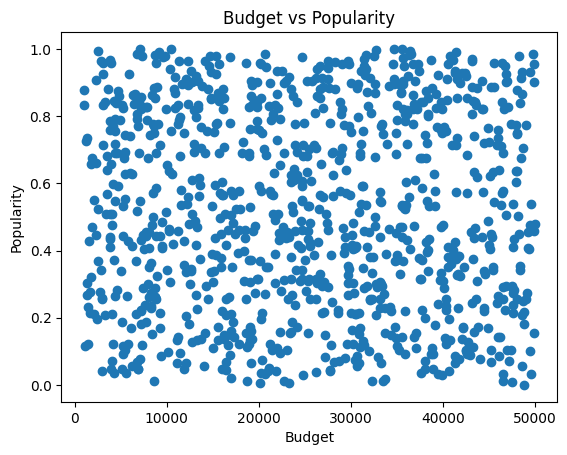

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['Budget'], df['Popularity'])
plt.xlabel("Budget")
plt.ylabel("Popularity")
plt.title("Budget vs Popularity")
plt.show()

In [10]:
best_cluster = df.groupby('Cluster')['ExperienceRating'].mean().idxmax()

print("Best Cluster:", best_cluster)

print(df[df['Cluster'] == best_cluster].head())


Best Cluster: 1
    UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  Cluster
0        1            941     3              1.00    0.571614    8575        1
1        1            467     1              0.50    0.261105    8055        1
9        8             50     0              1.00    0.338783    5033        1
10       8            204     4              1.00    0.230031    8298        1
11       9            959     4              0.25    0.775843   11217        1


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['ExperienceRating', 'Popularity', 'Budget']])

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

print(df.head())

   UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  Cluster
0       1            941     3              1.00    0.571614    8575        0
1       1            467     1              0.50    0.261105    8055        1
2       2            385     0              1.00    0.273994   49165        1
3       2            437     1              0.25    0.241870   39462        3
4       3            904     4              0.75    0.536195   35628        0


In [13]:
df['Score'] = (
    df['ExperienceRating'] * 0.5 +
    df['Popularity'] * 0.3 +
    (1 / df['Budget']) * 0.2
)

In [14]:
def smart_recommend(budget, min_exp):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_exp)
    ]

    return result.sort_values(by='Score', ascending=False).head(5)

# Example
print(smart_recommend(15000, 0.5))

     UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  \
598     597            386     3               1.0    0.981718    8696   
327     324             38     2               1.0    0.979390    7322   
879     876              8     2               1.0    0.979398   14715   
734     742            281     3               1.0    0.965446   14123   
868     868            661     3               1.0    0.924675    3104   

     Cluster     Score  
598        0  0.794538  
327        0  0.793844  
879        0  0.793833  
734        0  0.789648  
868        0  0.777467  


In [15]:
def personalized_plan(user_id):
    user_data = df[df['UserID'] == user_id]

    if user_data.empty:
        return "No data for this user"

    avg_budget = user_data['Budget'].mean()
    avg_exp = user_data['ExperienceRating'].mean()

    return smart_recommend(avg_budget, avg_exp)

# Example
print(personalized_plan(1))

     UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  \
327     324             38     2               1.0    0.979390    7322   
868     868            661     3               1.0    0.924675    3104   
972     968            567     1               1.0    0.843608    7003   
484     474             24     4               1.0    0.840933    3307   
208     215            242     1               1.0    0.832045    1011   

     Cluster     Score  
327        0  0.793844  
868        0  0.777467  
972        0  0.753111  
484        0  0.752340  
208        0  0.749811  


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(scaled_features)

def recommend_advanced(index):
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top = [i[0] for i in scores[1:6]]
    return df.iloc[top][['DestinationID', 'Score', 'Budget']]

print(recommend_advanced(0))

     DestinationID     Score  Budget
851            874  0.675504    8864
619            624  0.499318    6214
37             239  0.688434   10643
566            899  0.661015   11600
671            507  0.485697    6686


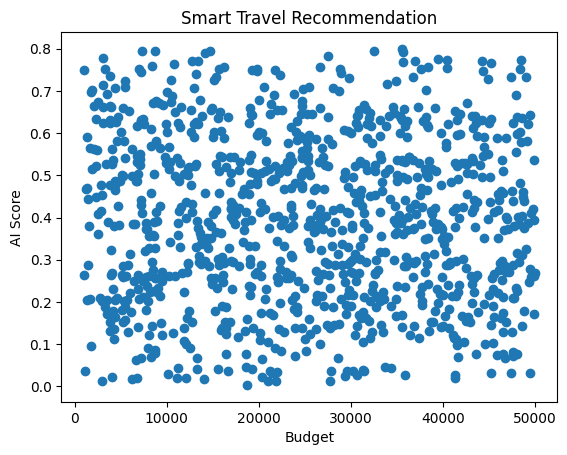

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df['Budget'], df['Score'])
plt.xlabel("Budget")
plt.ylabel("AI Score")
plt.title("Smart Travel Recommendation")
plt.show()

In [18]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.4 MB/s eta 0:00:00


In [19]:
import streamlit as st
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("final_travel_data (project) (1).csv")

# Drop unnecessary column
if 'Rating' in df.columns:
    df = df.drop(columns=['Rating'])

df = df.dropna()

# Scale features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['ExperienceRating', 'Popularity', 'Budget']])

# Train model
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Create score
df['Score'] = (
    df['ExperienceRating'] * 0.5 +
    df['Popularity'] * 0.3 +
    (1 / df['Budget']) * 0.2
)

# Function
def smart_recommend(budget, min_exp):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_exp)
    ]
    return result.sort_values(by='Score', ascending=False).head(5)

# UI
st.title("🌍 AI Travel Planner")

st.write("Enter your preferences:")

budget = st.slider("Select Budget", 1000, 50000, 10000)
experience = st.slider("Minimum Experience Rating", 0.0, 1.0, 0.5)

if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)

    st.subheader("Top Recommendations:")
    st.write(result[['DestinationID', 'Budget', 'ExperienceRating', 'Score']])

2026-04-21 08:47:57.556 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.832 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-21 08:47:57.834 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:47:57.841 Thread 'MainThread': mi

In [20]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("final_travel_data (project) (1).csv")

# Drop unnecessary column
if 'Rating' in df.columns:
    df = df.drop(columns=['Rating'])

df = df.dropna()

# Scale features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['ExperienceRating', 'Popularity', 'Budget']])

# Train model
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Score
df['Score'] = (
    df['ExperienceRating'] * 0.5 +
    df['Popularity'] * 0.3 +
    (1 / df['Budget']) * 0.2
)

# Function
def smart_recommend(budget, min_exp):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_exp)
    ]
    return result.sort_values(by='Score', ascending=False).head(5)

# UI
st.title("🌍 AI Travel Planner")

budget = st.slider("Select Budget", 1000, 50000, 10000)
experience = st.slider("Minimum Experience Rating", 0.0, 1.0, 0.5)

if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)
    st.write(result[['DestinationID', 'Budget', 'ExperienceRating', 'Score']])

Writing app.py


In [22]:
import os
print(os.listdir())

['.config', 'app.py', 'final_travel_data (project) (1).csv', 'sample_data']


In [23]:
!pip install pyngrok

In [24]:
!ngrok config add-authtoken 3BvwREXKncXlrgUeD8uYlYMwU0S_72tEKRWxZZfjoks7CqgQw

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [25]:
from pyngrok import ngrok
import os

# Run streamlit in background
get_ipython().system_raw('streamlit run app.py &')

# Create public URL
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://civilizational-uncavernously-berry.ngrok-free.dev" -> "http://localhost:8501"


In [26]:
destination_map = {
    101: "Goa",
    102: "Manali",
    103: "Ooty",
    104: "Jaipur",
    105: "Kerala",
    106: "Delhi",
    107: "Mumbai",
    108: "Kashmir",
    109: "Hyderabad",
    110: "Bangalore"
}

In [27]:
df['Place'] = df['DestinationID'].map(destination_map)

In [28]:
if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)
    st.write(result[['DestinationID','Budget','ExperienceRating','Score']])


2026-04-21 08:48:43.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:43.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:43.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:43.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:43.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:43.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [29]:
result = smart_recommend(10000, 0.5)
print(result.head())


     UserID  DestinationID  Type  ExperienceRating  Popularity  Budget  \
598     597            386     3               1.0    0.981718    8696   
327     324             38     2               1.0    0.979390    7322   
868     868            661     3               1.0    0.924675    3104   
481     473            443     2               1.0    0.862422    8381   
972     968            567     1               1.0    0.843608    7003   

     Cluster     Score Place  
598        0  0.794538   NaN  
327        0  0.793844   NaN  
868        0  0.777467   NaN  
481        0  0.758751   NaN  
972        0  0.753111   NaN  


In [30]:
if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)

    st.subheader("🌍 Recommended Destinations")
    st.write(result[['Place','Budget','ExperienceRating','Score']])

2026-04-21 08:48:49.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:49.211 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:49.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:49.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:49.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:49.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [31]:
print(df['DestinationID'].unique())

[ 941  467  385  437  904  421  425  670  953   50  204  959  996  890
   89  994  340  222  701  481  970   40  176  610  764  883  582  311
  674  489  725  272  952  130  702  505  239  978  886  910  297   91
  977  573  909  654  189  500  468  653  200  230  925  474  487   21
  114  224  951  938  678  271  808   92  320  339  825  747  494  118
  922  835  170   41  840  714  315  801  310   29  803   61  581  493
  873   49  648  805  360   14  254  889  383  153  954  477  101  833
  920  847  280   67  617  398   37   53  537  984  849  511  828  635
  655  357  737  405  691  485  366  154  402  945  235  348  622  148
  881  983  330  586  399  240  839  967  242  836  818  305  707  939
  709  301  368  720  864  567  552   96   58  519  698  259  932  331
  196  392  946  784  175   17  466  142  960  869    7  532  394  878
  768  986  717  387  389  898  728  396  826  774  988  205  354  587
  727   42  905  417  112  188  174  258  484  606  273  223   64  395
  565 

In [32]:
st.success("Trip Planned Successfully! 🎉")

2026-04-21 08:48:54.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:54.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:48:54.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("final_travel_data (project) (1).csv")

# Drop unnecessary column
if 'Rating' in df.columns:
    df = df.drop(columns=['Rating'])

df = df.dropna()

# Mapping for place names
destination_map = {
    1: "Goa",
    2: "Manali",
    3: "Ooty",
    4: "Jaipur",
    5: "Kerala",
    6: "Delhi",
    7: "Mumbai",
    8: "Kashmir",
    9: "Hyderabad",
    10: "Bangalore"
}

df['Place'] = "Place " + df['DestinationID'].astype(str)

# Scale features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['ExperienceRating', 'Popularity', 'Budget']])

# Model
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Score
df['Score'] = (
    df['ExperienceRating'] * 0.5 +
    df['Popularity'] * 0.3 +
    (1 / df['Budget']) * 0.2
)

# Recommendation function
def smart_recommend(budget, min_exp):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_exp)
    ]
    return result.sort_values(by='Score', ascending=False).head(5)

# UI
st.title("🌍 AI Travel Planner")

budget = st.slider("Select Budget", 1000, 50000, 10000)
experience = st.slider("Minimum Experience Rating", 0.0, 1.0, 0.5)

if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)

    st.subheader("🌍 Recommended Destinations")
    st.write(result[['Place','Budget','ExperienceRating','Score']])
    st.success("Trip Planned Successfully! 🎉")

Overwriting app.py


In [34]:
places = [
    "Goa", "Ooty", "Manali", "Jaipur", "Kerala", "Delhi", "Mumbai",
    "Kashmir", "Hyderabad", "Bangalore", "Agra", "Shimla", "Darjeeling",
    "Mysore", "Pondicherry", "Varanasi", "Amritsar", "Udaipur",
    "Rishikesh", "Andaman", "Leh Ladakh", "Coorg", "Chennai",
    "Kolkata", "Ahmedabad", "Surat", "Pune", "Nagpur",
    "Visakhapatnam", "Tirupati", "Madurai", "Trivandrum"
]

In [35]:
unique_ids = df['DestinationID'].unique()

destination_map = {}
for i, id_val in enumerate(unique_ids):
    destination_map[id_val] = places[i % len(places)]

df['Place'] = df['DestinationID'].map(destination_map)

In [36]:
places = places * 50

In [37]:
st.write(result[['Place','Budget','ExperienceRating','Score']])

2026-04-21 08:49:06.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:06.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:06.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [38]:
import streamlit as st
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("final_travel_data (project) (1).csv")

# Drop unnecessary column
if 'Rating' in df.columns:
    df = df.drop(columns=['Rating'])

df = df.dropna()

# REAL TOURIST PLACE NAMES (BIG LIST)
places = [
    "Goa", "Ooty", "Manali", "Jaipur", "Kerala", "Delhi", "Mumbai",
    "Kashmir", "Hyderabad", "Bangalore", "Agra", "Shimla", "Darjeeling",
    "Mysore", "Pondicherry", "Varanasi", "Amritsar", "Udaipur",
    "Rishikesh", "Andaman", "Leh Ladakh", "Coorg", "Chennai",
    "Kolkata", "Ahmedabad", "Surat", "Pune", "Nagpur",
    "Visakhapatnam", "Tirupati", "Madurai", "Trivandrum"
]

# MAP ALL IDs TO PLACE NAMES
unique_ids = df['DestinationID'].unique()

destination_map = {}
for i, id_val in enumerate(unique_ids):
    destination_map[id_val] = places[i % len(places)]

df['Place'] = df['DestinationID'].map(destination_map)

# Scale features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['ExperienceRating', 'Popularity', 'Budget']])

# Model
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Score calculation
df['Score'] = (
    df['ExperienceRating'] * 0.5 +
    df['Popularity'] * 0.3 +
    (1 / df['Budget']) * 0.2
)

# Recommendation function
def smart_recommend(budget, min_exp):
    result = df[
        (df['Budget'] <= budget) &
        (df['ExperienceRating'] >= min_exp)
    ]
    return result.sort_values(by='Score', ascending=False).head(5)

# UI
st.title("🌍 AI Travel Planner")

budget = st.slider("Select Budget", 1000, 50000, 10000)
experience = st.slider("Minimum Experience Rating", 0.0, 1.0, 0.5)

if st.button("Plan My Trip ✈️"):
    result = smart_recommend(budget, experience)

    st.subheader("🌍 Recommended Destinations")
    st.write(result[['Place', 'Budget', 'ExperienceRating', 'Score']])
    st.success("Trip Planned Successfully! 🎉")

2026-04-21 08:49:08.402 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.406 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:49:08.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [39]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://civilizational-uncavernously-berry.ngrok-free.dev" -> "http://localhost:8501"


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Features and target
X = df[['ExperienceRating', 'Popularity', 'Budget']]
y = df['Type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models to compare
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Print results
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


Random Forest: 0.2650
Gradient Boosting: 0.3700
Logistic Regression: 0.1700
SVM (RBF Kernel): 0.2050
